# Оценка результатов A/B-теста для интернет-магазина BitMotion Kit

**Цель исследования:** провести оценку результатов A/B-теста для интернет-магазина BitMotion Kit и проверить гипотезу о том, что новый интерфейс онлайн-магазина повысил количество пользователей, которые совершат покупку, по сравнению с пользователями, использующими старый интерфейс, хотя бы на три процентных пункта.

**Задачи:**
1. Оценить соответствие проведенного теста техническому заданию.
2. Проверить гипотезу по результатам А/В-теста.
3. Сформулировать выводы по проведённому анализу.

## Загрузка данных

In [4]:
# Импортируем pandas для работы с данными:

import pandas as pd

# Импортируем библиотеки для визуализации:

import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеки для статистических расчетов
import scipy.stats as st
import numpy as np

In [5]:
participants = pd.read_csv('ab_test_participants.csv')
events = pd.read_csv('ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)

In [6]:
# Осмотрим данные:

display(participants.head(), participants.info())
display(events.head(), events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


None

Мы видим, что таблица `participants` состоит из 4 столбцов и 14525 строк. Содержание столбцов соответствует описанию. Наименования столбцов корректные и не требуют обработки. Все столбцы содержат данные типа `object`, что соответствует характеру хранимых даных. Все столбцы заполнены полностью, не имеют пропусков.

Таблица `events` состоит из 4 столбцов и 787286 строк. Содержание столбцов соответствует описанию. Наименования столбцов корректные и не требуют обработки. Три столбца содержат данные типа `object`, что соответствует характеру хранимых даных. Столбец `event_dt`, содержащий сведения о дате события, при чтении файла был приведен к типу `datetime64[ns]`. Все столбцы, кроме `details` заполнены полностью, не имеют пропусков. Cтолбец `details` содержит большое количество пропусков, однако это логично, поскольку не всякое событие `event` требует указания дополнительных данных в `details`.

## По таблице `ab_test_participants` оценим корректность проведения теста:

Выделим пользователей, участвующих в тесте, и проверим:

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Нужный нам тест называется `interface_eu_test`. Выберем из таблицы `participants` участников этого теста.

In [11]:
participants['ab_test'].unique()

array(['interface_eu_test', 'recommender_system_test'], dtype=object)

In [12]:
# Выберем участников теста 'interface_eu_test':

interface_eu_test_group = participants[participants['ab_test']=='interface_eu_test']

# Выберем участников теста 'recommender_system_test':

recommender_system_test_group = participants[participants['ab_test']=='recommender_system_test']

Проверим. что участники теста `interface_eu_test` не являются участниками конкурирующего теста `recommender_system_test`.

In [14]:
# Зададим множество участников первого теста:

interface_eu_test_group_users = set(interface_eu_test_group['user_id'])

# Зададим множество участников второго теста:

recommender_system_test_group_users = set(recommender_system_test_group['user_id'])

# Найдем пересечение множеств:

intersection = interface_eu_test_group_users.intersection(recommender_system_test_group_users)

if intersection == set():
    display('Участники тестов не пересекаются.')
else:
    display(f'Участники тестов пересекаются.')

'Участники тестов пересекаются.'

In [15]:
# Исключим участников конкурирующего теста из группы участников теста 'interface_eu_test':

interface_eu_test_group_filtered = interface_eu_test_group[~interface_eu_test_group['user_id'].isin(recommender_system_test_group['user_id'])]

In [16]:
# Зададим множество отфильтрованного датафрейма с участниками первого теста:

interface_eu_test_group_users = set(interface_eu_test_group_filtered['user_id'])

# Зададим множество участников второго теста:

recommender_system_test_group_users = set(recommender_system_test_group['user_id'])

# Найдем пересечение множеств:

intersection = interface_eu_test_group_users.intersection(recommender_system_test_group_users)

if intersection == set():
    display('Участники тестов не пересекаются.')
else:
    display(f'Участники тестов пересекаются.')

'Участники тестов не пересекаются.'

Мы получили таблицу `interface_eu_test_group_filtered` с участниками теста `interface_eu_test`, не участвующими в конкурирующем тесте. Далее разделим их на группы А и В.

In [19]:
# Выбираем группу А

a_group = interface_eu_test_group_filtered[interface_eu_test_group_filtered['group']=='A']

# Выбираем группу В

b_group = interface_eu_test_group_filtered[interface_eu_test_group_filtered['group']=='B']

display(a_group.head(),a_group.info())
display(b_group.head(),b_group.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4952 entries, 4 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  4952 non-null   object
 1   group    4952 non-null   object
 2   ab_test  4952 non-null   object
 3   device   4952 non-null   object
dtypes: object(4)
memory usage: 193.4+ KB


,user_id,group,ab_test,device
4,001E72F50D1C48FA,A,interface_eu_test,Mac
7,0031F1B5E9FBF708,A,interface_eu_test,Android
11,0036BE15EE4D319D,A,interface_eu_test,PC
13,003F86A34B575D27,A,interface_eu_test,Android
16,0050F43F34C955F4,A,interface_eu_test,PC


None

<class 'pandas.core.frame.DataFrame'>
Index: 5011 entries, 0 to 14519
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  5011 non-null   object
 1   group    5011 non-null   object
 2   ab_test  5011 non-null   object
 3   device   5011 non-null   object
dtypes: object(4)
memory usage: 195.7+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
8,003346BB64227D0C,B,interface_eu_test,Android
14,004C58ADE7CA8C4A,B,interface_eu_test,Android


None

Мы получили две группы пользователей - участников теста `interface_eu_test`. Группа А включает 4952 пользователя, группа В - 5011. Группы незначительно различаются количественно, что не препятствует проведению А/В-теста.

Теперь проверим данные на дубликаты и проверим нет ли в группах пересечений.

In [21]:
# Проверим данные на дубликаты:

a_group.duplicated(subset='user_id').sum()

0

In [22]:
b_group.duplicated(subset='user_id').sum()

0

In [23]:
# Зададим множество пользователей из группы А:

a_group_users = set(a_group['user_id'])

# Зададим множество пользователей из группы В:

b_group_users = set(b_group['user_id'])

# Найдем пересечение множеств:

intersection = a_group_users.intersection(b_group_users)

if intersection == set():
    display('Пользователи из групп А и В не пересекаются.')
else:
    display(f'Пользователи из групп А и В включают одинаковых пользователей:{intersection}')

'Пользователи из групп А и В не пересекаются.'

#### Промежуточный вывод

Мы сформировали две группы участников теста `interface_eu_test`, не пересекающихся с участниками конкурирующего теста и между собой. Группы являются независимыми и равномерными.

Теперь в таблице `ab_test_events` выберем только события, связанные с участвующими в изучаемом тесте пользователями.

In [26]:
# Из таблицы `events` выберем значения для участников теста `interface_eu_test`:

events_test = events[events['user_id'].isin(interface_eu_test_group_filtered['user_id'])]

display(events_test.head(),events_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 73815 entries, 64672 to 780371
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73815 non-null  object        
 1   event_dt    73815 non-null  datetime64[ns]
 2   event_name  73815 non-null  object        
 3   details     19450 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.8+ MB


,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


None

Определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации.

In [28]:
# Найдем для каждого пользователя дату регистрации: отберем события 'registration'
# Сгруппируем данные по user_id, указавав для каждого минимальную дату регистрации (на случай, если их могло быть несколько)
# Сбрасываем индексы и называем столбец reg_dt

reg_dates = events_test[events_test['event_name'] == 'registration'].groupby('user_id')['event_dt'].min().reset_index().rename(columns={'event_dt': 'reg_dt'})

In [29]:
# Теперь соединим датафреймы events_test и reg_dates:

events_test=events_test.merge(reg_dates, on='user_id', how='left')

In [30]:
events_test = events_test[events_test['reg_dt'].notna()]

In [31]:
# Отфильтруем датасет events_test, оставив только события, произошедшие в первые семь дней с момента регистрации:

mask = (
    (events_test['event_dt'] >= events_test['reg_dt']) &
    (events_test['event_dt'] <= events_test['reg_dt'] + pd.Timedelta(days=7))
)
events_test = events_test[mask]

events_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63805 entries, 0 to 73793
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     63805 non-null  object        
 1   event_dt    63805 non-null  datetime64[ns]
 2   event_name  63805 non-null  object        
 3   details     16125 non-null  object        
 4   reg_dt      63805 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(3)
memory usage: 2.9+ MB


In [32]:
# Проверяемый максимальную разницу между временем события и датой регистрации:

(events_test.event_dt - events_test.reg_dt).max()

Timedelta('6 days 23:58:10')

Мы получили выборку событий, произошедших в первые семь дней с момента регистрации. Проверка подтвердила, что крайнее событие произошло через 6 days 23:58:10 с момента регистрации.

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%,

- MDE - 3%.

In [38]:
# Для расчёта размера выборки используем калькулятор:

# Определяем функцию calculate_sample_size, которая принимает:
# p1 — базовую конверсию (контрольная группа),
# p2 — ожидаемую конверсию в тестовой группе,
# alpha — уровень значимости (по умолчанию 0.05, то есть 95% доверие),
# power — мощность теста (по умолчанию 0.8, или 80%).

def calculate_sample_size(p1, p2, alpha=0.05, power=0.8):

# Вычисляем критическое значение z для заданного уровня значимости alpha:

    z_alpha = st.norm.ppf(1 - alpha) 

# Вычисляем критическое значение z для мощности теста:
    
    z_beta = st.norm.ppf(power)
    
# Вычисляем среднюю конверсию между контрольной и тестовой группами:

    p = (p1 + p2) / 2
    
# Рассчитываем стандартную ошибку (SE) для объединённой пропорции:

    se_pool = (2 * p * (1 - p))**0.5
    
# Рассчитываем стандартную ошибку для разницы между двумя пропорциями:
    
    se_effect = (p1*(1-p1) + p2*(1-p2))**0.5
    
# Вычисляем числитель формулы размера выборки (cуммируем произведения критических z-значений на соответствующие стандартные ошибки, dозводим сумму в квадрат):
    
    numerator = (z_alpha * se_pool + z_beta * se_effect)**2
    
# Вычисляем знаменатель — квадрат минимального детектируемого эффекта (разницы конверсий):

    denominator = (p2 - p1)**2
    
# Делим числитель на знаменатель, получая размер выборки на одну группу:

    n = numerator / denominator
    
    return round(n)

# Задаём входные параметры для функции: 
# базовая конверсия 30%, 
# ожидаемая конверсия 33%, 
# уровень значимости 5%, 
# мощность 80%.

p1 = 0.30  # Базовая конверсия
p2 = 0.33  # Ожидаемая конверсия
alpha = 0.05
power = 0.80

# Вызываем функцию для расчёта размера выборки на одну группу:

sample_size_per_group = calculate_sample_size(p1, p2, alpha, power)

# Умножаем на 2, чтобы получить общий размер выборки для обеих групп (контрольной и тестовой):

total_sample_size = 2 * sample_size_per_group

# Выводим результаты — сколько пользователей нужно в каждой группе и всего:

print(f"Требуемый размер выборки на группу: {sample_size_per_group}")
print(f"Общий размер выборки: {total_sample_size}")


Требуемый размер выборки на группу: 2963
Общий размер выборки: 5926


#### Предварительный вывод

Ранее, мы получили две группы пользователей - участников теста `interface_eu_test`. Группа А включает 4952 пользователя, группа В - 5011. Требуемый размер выборки выполняется, то есть данных достаточно для проверки результатов А/В-теста. 

In [41]:
# Объединим датафрейм interface_eu_test_group_filtered и events_test:

events_test = events_test.merge(interface_eu_test_group_filtered, on='user_id', how='left')
display(events_test.head())

,user_id,event_dt,event_name,details,reg_dt,group,ab_test,device
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,A,interface_eu_test,iPhone
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,A,interface_eu_test,Android
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,B,interface_eu_test,iPhone
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,A,interface_eu_test,iPhone
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,B,interface_eu_test,PC


Для каждой группы рассчитаем количество посетителей, сделавших покупку, и общее количество посетителей.

In [43]:
# Добавим столбец `ispurchase` с флагом покупки:

def purchase_count (event_name):
    if event_name=='purchase':
        return 1
    else:
        return 0
    
events_test['ispurchase']=events_test['event_name'].apply(purchase_count)

events_test.head()

,user_id,event_dt,event_name,details,reg_dt,group,ab_test,device,ispurchase
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,A,interface_eu_test,iPhone,0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,A,interface_eu_test,Android,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,B,interface_eu_test,iPhone,0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,A,interface_eu_test,iPhone,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,B,interface_eu_test,PC,0


In [44]:
# Для каждого пользователя и группы определяем, была ли покупка

user_purchase = (events_test.groupby(['user_id', 'group'])['ispurchase'].max().reset_index())

# Посчитаем количество посетителей и количество покупок:

conversion = user_purchase.groupby('group').agg(user_count=('user_id', 'nunique'),
         purchase_count=('ispurchase', 'sum')).reset_index()

# Рассчитаем конвесию:

conversion['conversion_in_purchase'] = (conversion['purchase_count'] / conversion['user_count']).round(4)

display(conversion)


,group,user_count,purchase_count,conversion_in_purchase
0,A,4952,1377,0.2781
1,B,5011,1480,0.2954


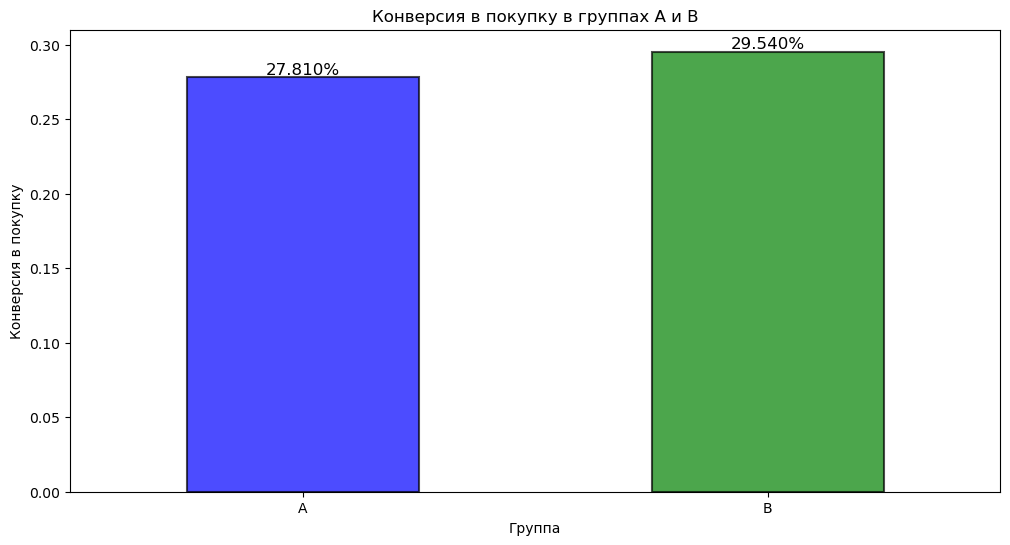

In [48]:
# Зададим цвета для столбцов:

colors = ['blue','green']

# Построим столбчатую диаграмму по столбцу с конверсией (сделаем значения столбца group индексами для отображения на оси х):

ax = conversion[['group','conversion_in_purchase']].set_index('group')['conversion_in_purchase'].plot(
    kind='bar',
    figsize=(12,6),
    edgecolor='black',
    linewidth=1.5,
    alpha=0.7,
    rot=0,
    color=colors,
    legend=False  
)

plt.xlabel('Группа')
plt.ylabel('Конверсия в покупку')
plt.title('Конверсия в покупку в группах А и В')

# Добавляем подписи значений над столбцами
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3%}', 
                (p.get_x() + p.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=12)

plt.show()


#### Предварительный вывод

Для каждой группы тестирования мы рассчитали количество уникальных посетителей сайта за первые семь дней с момента регистрации, количество посетителей, совершивших покупку в первые семь дней с момента регистрации, и конверсию в покупку. Конверсия в группе А получилась 27.81%, конверсия в группе В - 29.54%. То есть конверсия выросла на 1.73%.

## Оценка результатов A/B-тестирования

#### Проверим статистическую значимость изменения конверсии

Проверим, что конверсия в покупку в группе В выше конверсии в покупку в группе А не менее, чем на три процента.

Действовать будем по алгоритму проверки гипотез:

**1. Определяем тип гипотезы.** Нам необходимо проверить, что конверсия в покупку в группе В выше конверсии в покупку в группе А, то есть альтернативная гипотеза является односторонней, а именно - правосторонней, поскольку нас интересует отклонение в большую сторону. 

**2. Формулируем нулевую и альтернативную гипотезы.**

Нулевая гипотеза(Н0): конверсия в покупку в группе В равна конверсия в покупку в группе А.

Альтернативная гипотеза (Н1): конверсия в покупку в группе В больше конверсия в покупку в группе А.

**3. Выбираем уровень значимости α**
Поскольку ситуация обычная и не требует повышенной осторожности, то выбираем уровень значимости α = 0.05

**4. Выбираем статистический тест для проверки гипотезы.** Поскольку мы сравниваем вероятность успеха (конверсию в покупку) в двух независимых выборках, то для этих целей походит z-тест пропорций.

In [54]:
conversion

,group,user_count,purchase_count,conversion_in_purchase
0,A,4952,1377,0.2781
1,B,5011,1480,0.2954


In [55]:
from statsmodels.stats.proportion import proportions_ztest

# Запишем размеры выборок в переменные:

n_a = conversion.loc[conversion['group']=='A','user_count'].values[0]

n_b = conversion.loc[conversion['group']=='B','user_count'].values[0]

# Запишем количество успехов в переменные:

m_a = conversion.loc[conversion['group']=='A','purchase_count'].values[0]

m_b = conversion.loc[conversion['group']=='B','purchase_count'].values[0]

# Запишем вероятности успехов в переменные:

p_a = m_a / n_a
p_b = m_b / n_b

# Проверим выполнение предпосылки о достаточном количестве данных для z-теста пропорций:

if (p_a * n_a > 10) and ((1 - p_a) * n_a > 10) and (p_b * n_b > 10) and ((1 - p_b) * n_b > 10): 
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

# Запишем в переменную выбранное значение уровня значимости:

alpha = 0.05

# Проведем z-тест пропорций:

stat_ztest, p_value_ztest = proportions_ztest([m_a,m_b],[n_a,n_b],alternative='smaller')

# Выведем р-значение:

print('p-значение:',p_value_ztest)

# Проверим гипотезу, сравнив р-значение с уровнем значимости:

if p_value_ztest < alpha:
    print('Отвергаем нулевую гипотезу. Конверсия в покупку в группе В больше конверсии в покупку в группе А.')
else:
    print('Не получилось отвергнуть нулевую гипотезу о том, что конверсия в покупку в группе В равна конверсия в покупку в группе А.')

# Проверим условие о росте конверсии хотя бы на 3%:    

observed_diff = p_b - p_a
mde = 0.03

if observed_diff < mde:
    print(f"Разница в конверсии ({observed_diff:.3%}) меньше MDE ({mde:.3%}), статистическая значимость может быть недостоверной.")
else:
    print(f"Разница в конверсии ({observed_diff:.3%}) достигает или превышает MDE ({mde:.3%}).")

Предпосылка о достаточном количестве данных выполняется!
p-значение: 0.028262547212292124
Отвергаем нулевую гипотезу. Конверсия в покупку в группе В больше конверсии в покупку в группе А.
Разница в конверсии (1.728%) меньше MDE (3.000%), статистическая значимость может быть недостоверной.


## Итоговый вывод

**Целью эксперимента** была оценка результатов A/B-теста для интернет-магазина BitMotion Kit и проверка гипотезу о том, что новый интерфейс онлайн-магазина повысил количество пользователей, которые совершат покупку, по сравнению с пользователями, использующими старый интерфейс, хотя бы на три процентных пункта.

**Целевой метрикой** для эксперимента выбрана конверсия в покупку, которую считали как отношении количества покупателей, совершивших покупку, к количеству пользователей, посетивших сайт в течение первых семи дней с момента регистрации.

**В ходе эксперимента установлено, что конверсия в покупку среди пользователей, видевших новую версию сайта онлайн-магазина, увеличилась на 1.73%.**

Увеличение показателя подтверждается статистически. **Значение p-value** для оценки статистической значимости выявленного эффекта **составило 0.028**, что можно интерпретировать так: если нулевая гипотеза верна и конверсия в покупку в группе В равна конверсии в покупку в группе А, то вероятность получить такое соотношение количества покупок к  количеству пользователей, посетивших сайт в течение первых семи дней с момента регистрации, как в данных эксперимента составляет 2.8%, то есть меньше установленного нами уровня значимости в 5%, что позволяет нам отвергнуть нулевую гипотезу и утверждать, что конверсия в покупку в группе В больше конверсии в покупку в группе А. 

При сравнении разницы в конверсии между группами (1.73%), определено, что она меньше установленного минимально детектируемого эффекта (MDE 3%), что говорит о том, что статистическая значимость полученного результата может быть недостоверной.

Несмотря на то, что новый интерфейс онлайн-магазина повысил количество пользователей, которые совершили покупку, по сравнению с пользователями, использующими старый интерфейс, на 1.73%, однако это увеличение меньше установленного минимально детектируемого эффекта (MDE 3%), что позволяет нам говорить **о нецелесообразности обновления интерфейса онлайн-магазина**.

<div style="border:solid Chocolate 2px; padding: 40px">
        
**Общий вывод по проекту ревьювера**:
         Спасибо за  проект, качественную отработку моих комментариев и хорошую обратную связь! Ты приложил много усилий, чтобы довести его до конца, проделана огромная работа, и это видно невооруженным глазом, ты большой молодец! У тебя отлично развиты аналитические способности и владение инструментарием.
        
**Отмечу положительные моменты**:
        
        1. Все разложено по полочкам, всегда понятен ход твоих мыслей, приятно смотреть.
        
        2. Понятные и логичные выводы на всех этапах работы.
        
        3. Лаконичное оформление проекта в целом.      
        
        4. Внимание к деталям в анализе  и выборе параметров тестов

        5. Оптимальное написание элементов кода
        
     
        
        
        
        
**Поздравляю тебя, еще одна аналитическая работа попадает в твое портфолио. Желаю успешного и интересного продолжения учебы!**
        
        